<a href="https://colab.research.google.com/github/anilkumargangadhara09/GenAI-ML/blob/main/Anil_NLP_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import required libs
##

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load train and test data

In [2]:
# data loading train and test

try:
    train_df = pd.read_csv('/content/train_tweet.csv', encoding='latin-1', header=0)
    test_df = pd.read_csv('/content/test_tweets.csv', encoding='latin-1', header=0)

    if train_df.empty or test_df.empty :
        print("The Data is empty. Please check the file contents.")
        exit()
    if 'train_df' in locals() or 'train_df' in globals() and 'test_df' in locals() or 'test_df' in globals():
        print("Data loaded successfully.")
        # Display the first few rows to verify
        display(train_df.head(5))
        # display(test_df.head(2))
    else:
        print("Failed to load the Data.")

except FileNotFoundError:
    print("File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")
    exit()

Data loaded successfully.


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
test_df.head(5)

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [4]:
print(train_df.shape)
print(test_df.shape)

(31962, 3)
(17197, 2)


## Exploratory data analysis

In [5]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17197 entries, 0 to 17196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      17197 non-null  int64 
 1   tweet   17197 non-null  object
dtypes: int64(1), object(1)
memory usage: 268.8+ KB


In [6]:
train_df.describe()
# test_df.describe()

,id,label
count,31962.000000,31962.000000
mean,15981.500000,0.070146
std,9226.778988,0.255397
min,1.000000,0.000000
25%,7991.250000,0.000000
50%,15981.500000,0.000000
75%,23971.750000,0.000000
max,31962.000000,1.000000


In [7]:
print(f'train df null: \n', train_df.isnull().any())
print(f'test df null: \n', test_df.isnull().any())

train df null: 
 id       False
label    False
tweet    False
dtype: bool
test df null: 
 id       False
tweet    False
dtype: bool


In [8]:
# checking out the postive comments from the train set

train_df[train_df['label'] == 1].head(5)

,id,label,tweet
13,14,1,@user #cnn calls #michigan middle school 'buil...
14,15,1,no comment! in #australia #opkillingbay #se...
17,18,1,retweet if you agree!
23,24,1,@user @user lumpy says i am a . prove it lumpy.
34,35,1,it's unbelievable that in the 21st century we'...


In [9]:
# checking out the negative comments from the train set

train_df[train_df['label'] == 0].head(5)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## The distribution of tweet

<Axes: xlabel='label'>

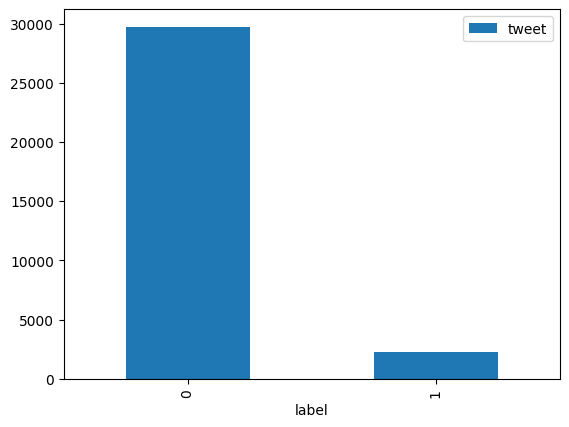

In [10]:
# values count
train_df['label'].value_counts()

# The distribution of sentiments
train_df[['label', 'tweet']].groupby('label').count().plot(kind='bar')

<Axes: ylabel='Frequency'>

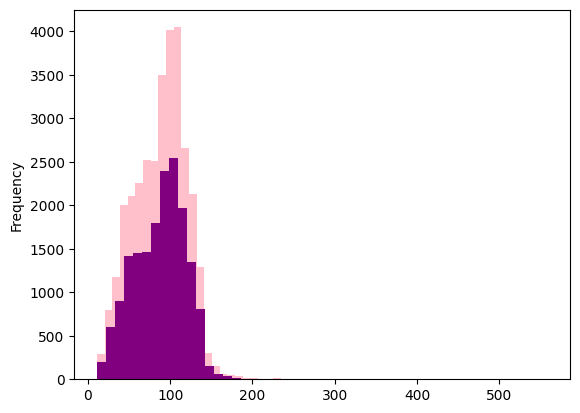

In [11]:
train_df['tweet'].str.len().plot(kind='hist', bins=50, color='pink')
test_df['tweet'].str.len().plot(kind='hist', bins=50, color='purple')

   label  count
0      0  29720
1      1   2242


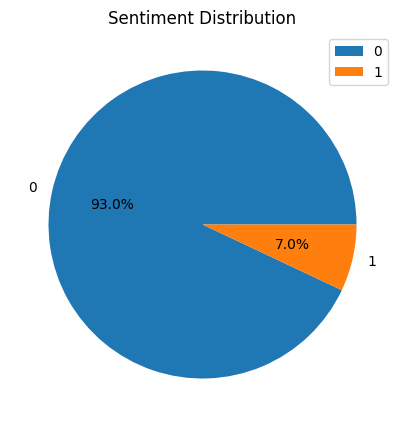

In [12]:
df_label = train_df.label.value_counts().reset_index()

print(df_label)
plt.figure(figsize=(5,5))
plt.pie(df_label['count'], labels=df_label['label'], autopct='%1.1f%%')
plt.legend()
plt.title('Sentiment Distribution')
plt.show()

## Feature Extraction

In [13]:
# Feature engineering
# adding a column to represent the length of the tweet
train_df['tweet_len'] = train_df['tweet'].apply(len)
test_df['tweet_len'] = test_df['tweet'].apply(len)

train_df.head(5)

,id,label,tweet,tweet_len
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,118
4,5,0,factsguide: society now #motivation,39


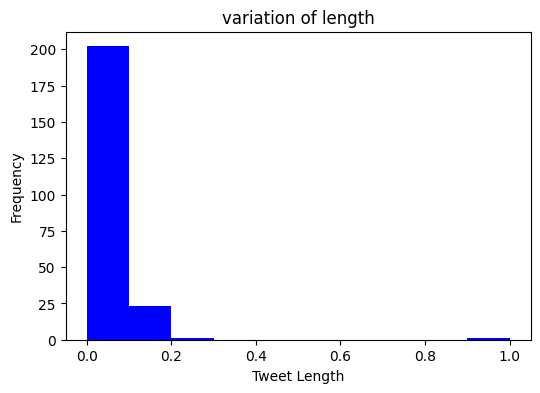

In [14]:
train_df.groupby('tweet_len')['label'].mean().plot.hist(color='blue', figsize=(6,4))
# train_df.groupby('len').mean()['label'].plot.hist(color = 'black', figsize = (6, 4),)
plt.xlabel('Tweet Length')
# plt.ylabel('Mean Label')
plt.title('variation of length')
plt.show()

 **Count Vectorizer**:
CountVectorizer is a text preprocessing technique commonly used in natural language processing (NLP) tasks for converting a collection of text documents into a numerical representation. It is part of the scikit-learn library

**Why:** Vectorization is needed because machine learning models work with numbers, not text. To analyze, classify, or make predictions based on text data, the text must first be transformed into a numerical form that these models can process.



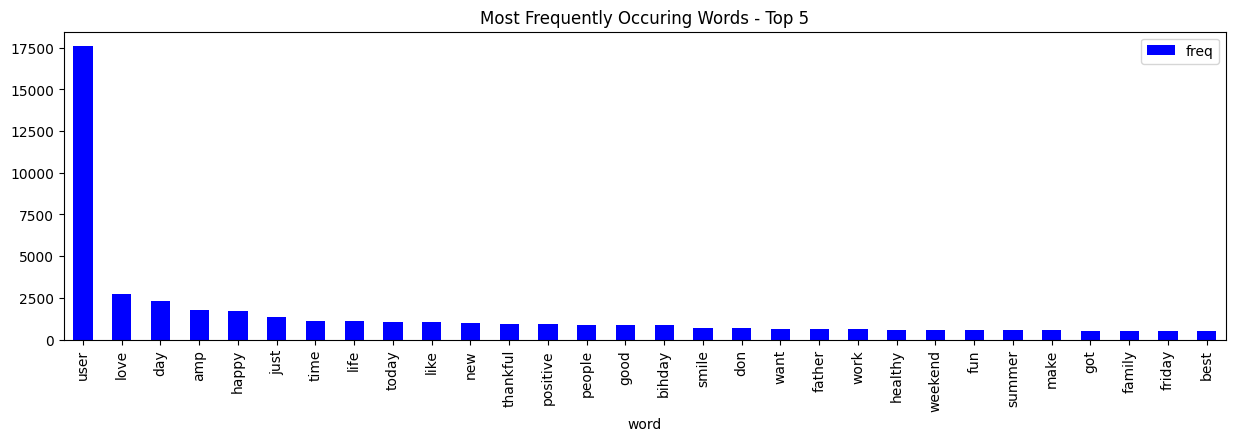

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Convert a collection of text documents to a matrix of token counts.
# Create an instance of CountVectorizer
cv = CountVectorizer(stop_words='english', lowercase=False)

words = cv.fit_transform(train_df['tweet'])

# print(words)

sum_words = words.sum(axis=0)
# print(sum_words)

words_freq = [(word, sum_words[0, i]) for word, i in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

frequency = pd.DataFrame(words_freq, columns=['word', 'freq'])

frequency.head(30).plot(x='word', y='freq', kind='bar', figsize=(15, 4), color='blue')
plt.title("Most Frequently Occuring Words - Top 5")
plt.show()



**Word Cloud**

Wordcloud is the pictorial representation of the word frequency of the dataset.WordCloud is easier to understand and gives a better idea about our textual data

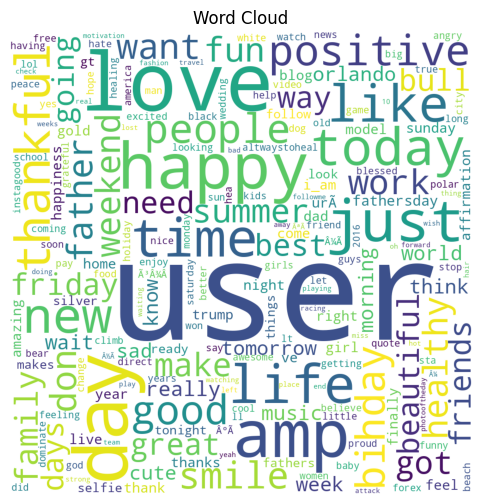

In [16]:
from wordcloud import WordCloud

wordcloud = WordCloud(background_color = 'white', width = 1000, height = 1000).generate_from_frequencies(dict(words_freq))

plt.figure(figsize=(8,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud')
plt.show()

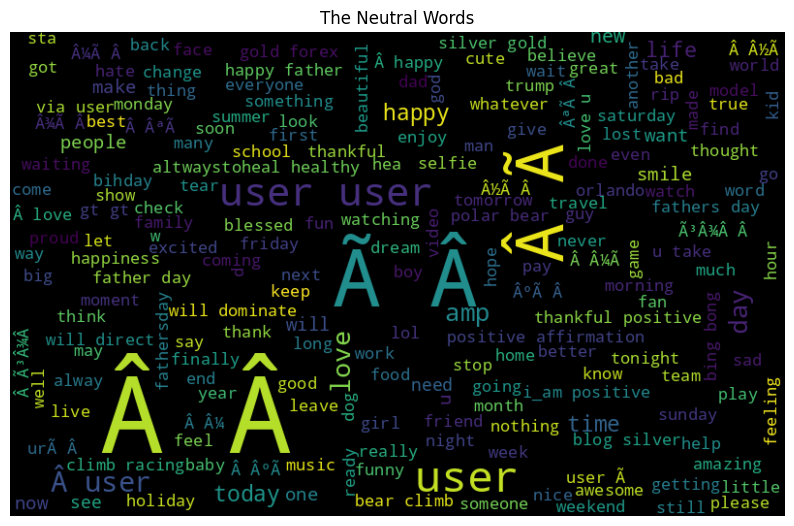

In [17]:
# Concatenates all tweets with `label == 0` into one long string (`normal_words`).

normal_words =' '.join([text for text in train_df['tweet'][train_df['label'] == 0]])

wordcloud = WordCloud(width=800, height=500, random_state = 0, max_font_size = 110).generate(normal_words)

plt.figure(figsize=(10, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis('off')

plt.title('The Neutral Words')

plt.show()

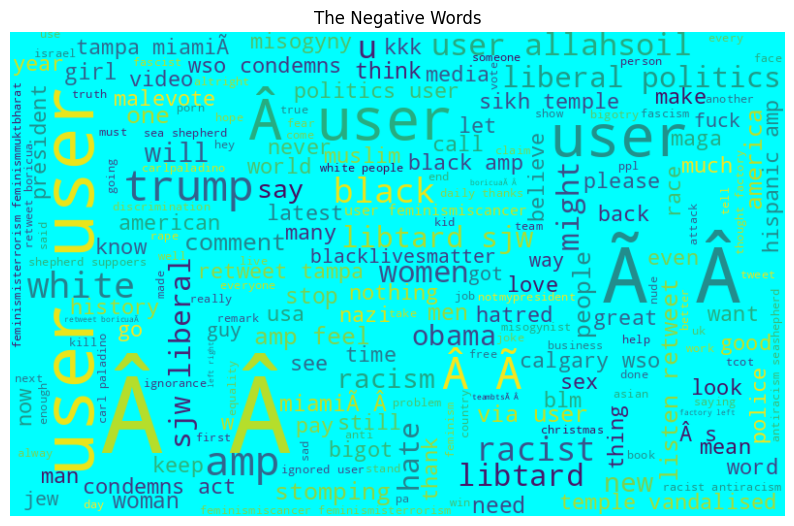

In [18]:
# Joins all tweets with `label == 1` into one long string (`negative_words`).
negative_words =' '.join([text for text in train_df['tweet'][train_df['label'] == 1]])
# Generates a word cloud from that text (size 800×500, cyan background, fixed randomness, max font size 110).

wordcloud = WordCloud(background_color = 'cyan', width=800, height=500, random_state = 0, max_font_size = 110).generate(negative_words)

plt.figure(figsize=(10, 7))

plt.imshow(wordcloud, interpolation="bilinear") # Displays the word cloud with smooth (bilinear) interpolation.

plt.axis('off')

plt.title('The Negative Words')

plt.show()

In [19]:
import re

def hastag_extract(x):
  hashtags = []
  for i in x:
    ht = re.findall(r"#(\w+)", i)
    hashtags.append(ht)

  return hashtags

In [20]:
ht_req = hastag_extract(train_df['tweet'][train_df['label']==0])
ht_neg = hastag_extract(train_df['tweet'][train_df['label']==1])

print(sum(ht_req,[]))
print(sum(ht_neg,[]))

['run', 'lyft', 'disapointed', 'getthanked', 'model', 'motivation', 'allshowandnogo', 'school', 'exams', 'hate', 'imagine', 'actorslife', 'revolutionschool', 'girl', 'allin', 'cavs', 'champions', 'cleveland', 'clevelandcavaliers', 'gr8', 'ireland', 'blog', 'silver', 'gold', 'forex', 'orlando', 'standwithorlando', 'pulseshooting', 'orlandoshooting', 'biggerproblems', 'selfish', 'heabreaking', 'values', 'love', '80days', 'gettingfed', 'got7', 'junior', 'yugyoem', 'omg', 'thankful', 'positive', 'friday', 'cookies', 'euro2016', 'badday', 'coneofshame', 'cats', 'pissed', 'funny', 'laughs', 'wine', 'weekend', 'tgif', 'ff', 'gamedev', 'indiedev', 'indiegamedev', 'squad', 'upsideofflorida', 'shopalyssas', 'love', 'smiles', 'media', 'pressconference', 'antalya', 'turkey', 'throwback', 'ica16', 'rip', 'orlando', 'alohafriday', 'time', 'not', 'exist', 'positivevibes', 'hawaiian', 'goodnight', 'badmonday', 'taylorswift1989', 'travelingram', 'dalat', 'ripinkylife', 'photoshop', 'enoughisenough', 'd

In [21]:
# # Tokenization and Word2Vec (simple steps)
# # Splits each training tweet into a list of words: `tokenized_tweet = train['tweet'].apply(lambda x: x.split())`.
# # tokenizing the words present in the training set
# tokenized_tweet = train_df['tweet'].apply(lambda x: x.split())

# try:
#   import gensim
# except ModuleNotFoundError:
#   print("Please install gensim")
#   !pip install gensim
#   import gensim


# # creating a word to vector model

# model_w2v = gensim.models.Word2Vec(
#             tokenized_tweet,
#             size=200, # desired no. of features/independent variables
#             window=5, # context window size
#             min_count=2,
#             sg = 1, # 1 for skip-gram model
#             hs = 0,
#             negative = 10, # for negative sampling
#             workers= 2, # no.of cores
#             seed = 34)
# model_w2v.train(tokenized_tweet, total_examples= len(train_df['tweet']), epochs=20)

In [22]:
# !pip install numpy --upgrade

In [23]:
# from tqdm import tqdm
# tqdm.pandas(desc="progress-bar")
# from gensim.models.doc2vec import TaggedDocument

In [24]:
# def add_label(twt):
#     output = []
#     for i, s in zip(twt.index, twt):
#         output.append(TaggedDocument(s, ["tweet_" + str(i)]))
#     return output

# # label all the tweets
# labeled_tweets = add_label(tokenized_tweet)
# labeled_tweets[:6]

In [25]:
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

train_corpus = []

for i in range(0, 31962):
  review = re.sub('[^a-zA-Z]', ' ', train_df['tweet'][i])
  review = review.lower()
  review = review.split()

  ps = PorterStemmer()
  # stemming
  review = [ps.stem(word) for word in review if not word in set(stopwords.words('english'))]
  # joining them back with space
  review = ' '.join(review)
  train_corpus.append(review)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [26]:
test_corpus = []

for i in range(0, 17197):
  review = re.sub('[^a-zA-Z]', ' ', test_df['tweet'][i])
  review = review.lower()
  review = review.split()

  ps = PorterStemmer()
  # stemming
  review = [ps.stem(word) for word in review if not word in set(stopwords.words('english'))]
  # joining them back with space
  review = ' '.join(review)
  test_corpus.append(review)

In [27]:
# creating bag of words
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features = 2500)

x = cv.fit_transform(train_corpus).toarray()

y = train_df.iloc[:, 1]

print(x.shape)
print(y.shape)

(31962, 2500)
(31962,)


In [28]:
# creating bag of words
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features = 2500)
x_test = cv.fit_transform(test_corpus).toarray()
print(x_test.shape)

(17197, 2500)


In [29]:
# splitting the training data into train and valid sets

from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size = 0.25, random_state = 42)

print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(23971, 2500)
(7991, 2500)
(23971,)
(7991,)


In [30]:
# standardization
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_valid = sc.transform(x_valid)
x_test = sc.transform(x_test)

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from joblib import Parallel, delayed

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVC": SVC(),
    "XGBoost": XGBClassifier(),
    # "Naive Bayes": GaussianNB(),
    # "KNN": KNeighborsClassifier(),
    # "AdaBoost": AdaBoostClassifier(),
    # "Gradient Boosting": GradientBoostingClassifier(),
    # "Bagging": BaggingClassifier()
}

def evaluate_model(model_name, model, x_train, y_train, x_valid, y_valid):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_valid)
    return {
        "Model": model_name,
        "Training Accuracy": model.score(x_train, y_train),
        "Validation Accuracy": model.score(x_valid, y_valid),
        "F1 Score": f1_score(y_valid, y_pred),
        # "Confusion Matrix": confusion_matrix(y_valid, y_pred)
    }

results = Parallel(n_jobs=-1)(delayed(evaluate_model)(name, model, x_train, y_train, x_valid, y_valid) for name, model in models.items())

model_eval = pd.DataFrame(results)

# for result in results:
#     print(f"{result['Model']} - Training Accuracy: {result['Training Accuracy']}")
#     print(f"{result['Model']} - Validation Accuracy: {result['Validation Accuracy']}")
#     print(f"{result['Model']} - F1 Score: {result['F1 Score']}")
#     print(f"{result['Model']} - Confusion Matrix:")
#     print(result['Confusion Matrix'])
#     print("\n")

evaluate = model_eval.sort_values(by="F1 Score", ascending=False)
print(evaluate)

Random Forest - Training Accuracy: 0.9991656585040257
Random Forest - Validation Accuracy: 0.9521962207483419
Random Forest - F1 Score: 0.610204081632653
Random Forest - Confusion Matrix:
[[7310  122]
 [ 260  299]]


Logistic Regression - Training Accuracy: 0.9852738725960536
Logistic Regression - Validation Accuracy: 0.9405581278938806
Logistic Regression - F1 Score: 0.5865970409051349
Logistic Regression - Confusion Matrix:
[[7179  253]
 [ 222  337]]


Decision Tree - Training Accuracy: 0.9991656585040257
Decision Tree - Validation Accuracy: 0.9314228507070454
Decision Tree - F1 Score: 0.5300171526586621
Decision Tree - Confusion Matrix:
[[7134  298]
 [ 250  309]]


SVC - Training Accuracy: 0.9781402528054732
SVC - Validation Accuracy: 0.9523213615317232
SVC - F1 Score: 0.49934296977660975
SVC - Confusion Matrix:
[[7420   12]
 [ 369  190]]


XGBoost - Training Accuracy: 0.9608693838388053
XGBoost - Validation Accuracy: 0.9549493179827305
XGBoost - F1 Score: 0.5714285714285714
XGBoost

In [32]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import f1_score

# model = RandomForestClassifier()
# model.fit(x_train, y_train)

# y_pred = model.predict(x_valid)


# print("Training Accuracy :", model.score(x_train, y_train))
# print("Validation Accuracy :", model.score(x_valid, y_valid))

# # calculating the f1 score for the validation set
# print("F1 score :", f1_score(y_valid, y_pred))

# # confusion matrix
# cm = confusion_matrix(y_valid, y_pred)
# print(cm)

In [33]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression()
# model.fit(x_train, y_train)

# y_pred = model.predict(x_valid)

# print("Training Accuracy :", model.score(x_train, y_train))
# print("Validation Accuracy :", model.score(x_valid, y_valid))

# # calculating the f1 score for the validation set
# print("f1 score :", f1_score(y_valid, y_pred))

# # confusion matrix
# cm = confusion_matrix(y_valid, y_pred)
# print(cm)

In [34]:
# from sklearn.tree import DecisionTreeClassifier

# model = DecisionTreeClassifier()
# model.fit(x_train, y_train)

# y_pred = model.predict(x_valid)

# print("Training Accuracy :", model.score(x_train, y_train))
# print("Validation Accuracy :", model.score(x_valid, y_valid))

# # calculating the f1 score for the validation set
# print("f1 score :", f1_score(y_valid, y_pred))

# # confusion matrix
# cm = confusion_matrix(y_valid, y_pred)
# print(cm)

In [35]:
# from sklearn.svm import SVC

# model = SVC()
# model.fit(x_train, y_train)

# y_pred = model.predict(x_valid)

# print("Training Accuracy :", model.score(x_train, y_train))
# print("Validation Accuracy :", model.score(x_valid, y_valid))

# # calculating the f1 score for the validation set
# print("f1 score :", f1_score(y_valid, y_pred))

# # confusion matrix
# cm = confusion_matrix(y_valid, y_pred)
# print(cm)

In [36]:
# from xgboost import XGBClassifier

# model = XGBClassifier()
# model.fit(x_train, y_train)

# y_pred = model.predict(x_valid)

# print("Training Accuracy :", model.score(x_train, y_train))
# print("Validation Accuracy :", model.score(x_valid, y_valid))

# # calculating the f1 score for the validation set
# print("f1 score :", f1_score(y_valid, y_pred))

# # confusion matrix
# cm = confusion_matrix(y_valid, y_pred)
# print(cm)

In [37]:
import os
import requests # this will connect with HTTPS and needs to have internet connectivity
from bs4 import BeautifulSoup # Web Scrapping Tools

In [38]:
#Asssing url that we need to scrape the data

url = "https://www.python.org/~guido/"

#Used to request data from the server. INcase this doesnot works in a single GO,

             # open the URL manually as this gets blocked often in office laptop



r = requests.get(url)

type(r)

requests.models.Response

In [39]:
#Saving the text part of webpage

html_doc = r.text
type(html_doc)

str

In [40]:
# Creating beautiful soup element

soup = BeautifulSoup(html_doc)

In [41]:
# Prettify() function in BeautifulSoup will enable us to view how the tags are

# nested in the document.

pretty_soup = soup.prettify()

type(pretty_soup)

# Print title of the webpage

guido_title = soup.title

guido_title

<title>Guido's Personal Home Page</title>

In [42]:
# Extracting text from beautiful soup element

guido_text = soup.get_text()

guido_text

'\n\nGuido\'s Personal Home Page\n\n\n\n\n\nGuido van Rossum - Personal Home Page\n\n\n"Gawky and proud of it."\nWho I Am\nRead\nmy "King\'s\nDay Speech" for some inspiration.\n\nI am the author of the Python\nprogramming language.  See also my resume\nand my publications list, a brief bio, assorted writings, presentations and interviews (all about Python), some\npictures of me,\nmy new blog, and\nmy old\nblog on Artima.com.  I am\n@gvanrossum on Twitter.\n\nI am currently a Distinguished Engineer at Microsoft.\nI have worked for Dropbox, Google, Elemental Security, Zope\nCorporation, BeOpen.com, CNRI, CWI, and SARA.  (See\nmy resume.)  I created Python while at CWI.\n\nHow to Reach Me\nYou can send email for me to guido (at) python.org.\nI read everything sent there, but I receive too much email to respond\nto everything.\n\nPlease understand that I do not give talks or keynotes any more,\nnor do I participate in podcasts or give interviews, etc.\nI am sorry, but I just receive too ma

In [43]:
# Find 'a' tags in HTML --- a tags contains the hyperlinks-

a_tags = soup.find_all('a')

a_tags

[<a href="pics.html"><img border="0" src="images/IMG_2192.jpg"/></a>,
 <a href="pics.html"><img border="0" height="216" src="images/guido-headshot-2019.jpg" width="270"/></a>,
 <a href="http://www.washingtonpost.com/wp-srv/business/longterm/microsoft/stories/1998/raymond120398.htm"><i>"Gawky and proud of it."</i></a>,
 <a href="images/df20000406.jpg">Who I Am</a>,
 <a href="http://neopythonic.blogspot.com/2016/04/kings-day-speech.html">"King's
 Day Speech"</a>,
 <a href="http://www.python.org">Python</a>,
 <a href="Resume.html">resume</a>,
 <a href="Publications.html">publications list</a>,
 <a href="bio.html">brief bio</a>,
 <a href="http://legacy.python.org/doc/essays/">writings</a>,
 <a href="http://legacy.python.org/doc/essays/ppt/">presentations</a>,
 <a href="interviews.html">interviews</a>,
 <a href="pics.html">pictures of me</a>,
 <a href="http://neopythonic.blogspot.com">my new blog</a>,
 <a href="http://www.artima.com/weblogs/index.jsp?blogger=12088">old
 blog</a>,
 <a href="

In [44]:
# To get all links from the webpage as list

for x in a_tags:

    print(x.get('href'))

pics.html
pics.html
http://www.washingtonpost.com/wp-srv/business/longterm/microsoft/stories/1998/raymond120398.htm
images/df20000406.jpg
http://neopythonic.blogspot.com/2016/04/kings-day-speech.html
http://www.python.org
Resume.html
Publications.html
bio.html
http://legacy.python.org/doc/essays/
http://legacy.python.org/doc/essays/ppt/
interviews.html
pics.html
http://neopythonic.blogspot.com
http://www.artima.com/weblogs/index.jsp?blogger=12088
https://twitter.com/gvanrossum
Resume.html
https://docs.python.org
https://github.com/python/cpython/issues
https://discuss.python.org
guido.au
http://legacy.python.org/doc/essays/
images/license.jpg
https://web.archive.org/
https://web.archive.org/web/20230627131911/http://www.cnpbagwell.com/audio-faq
http://sox.sourceforge.net/
images/internetdog.gif
